## Task 1 — Data Loading, EDA & Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

print("X shape:", X.shape)
print("\ny value counts:")
print(y.value_counts())

print("\nDescriptive Statistics:")
display(X.describe())

X shape: (569, 30)

y value counts:
target
1    357
0    212
Name: count, dtype: int64

Descriptive Statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [3]:
data.frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 1.2 Class Distribution

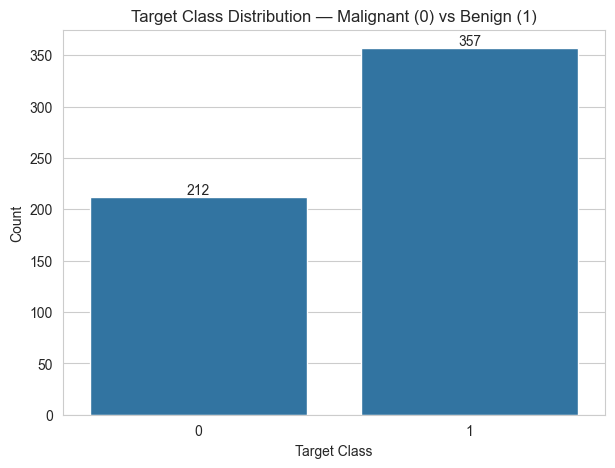

In [4]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(x=y)

plt.title('Target Class Distribution — Malignant (0) vs Benign (1)')
plt.xlabel('Target Class')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Class Imbalance:
The dataset contains 212 Malignant cases and 357 Benign cases. Therefore, the classes are not perfectly balanced, but the imbalance is mild. Since both classes have a reasonable number of samples, we can handle this by using a stratified train-test split so that the class proportions remain approximately the same in both sets.

## 1.3 Feature Correlation Heatmap

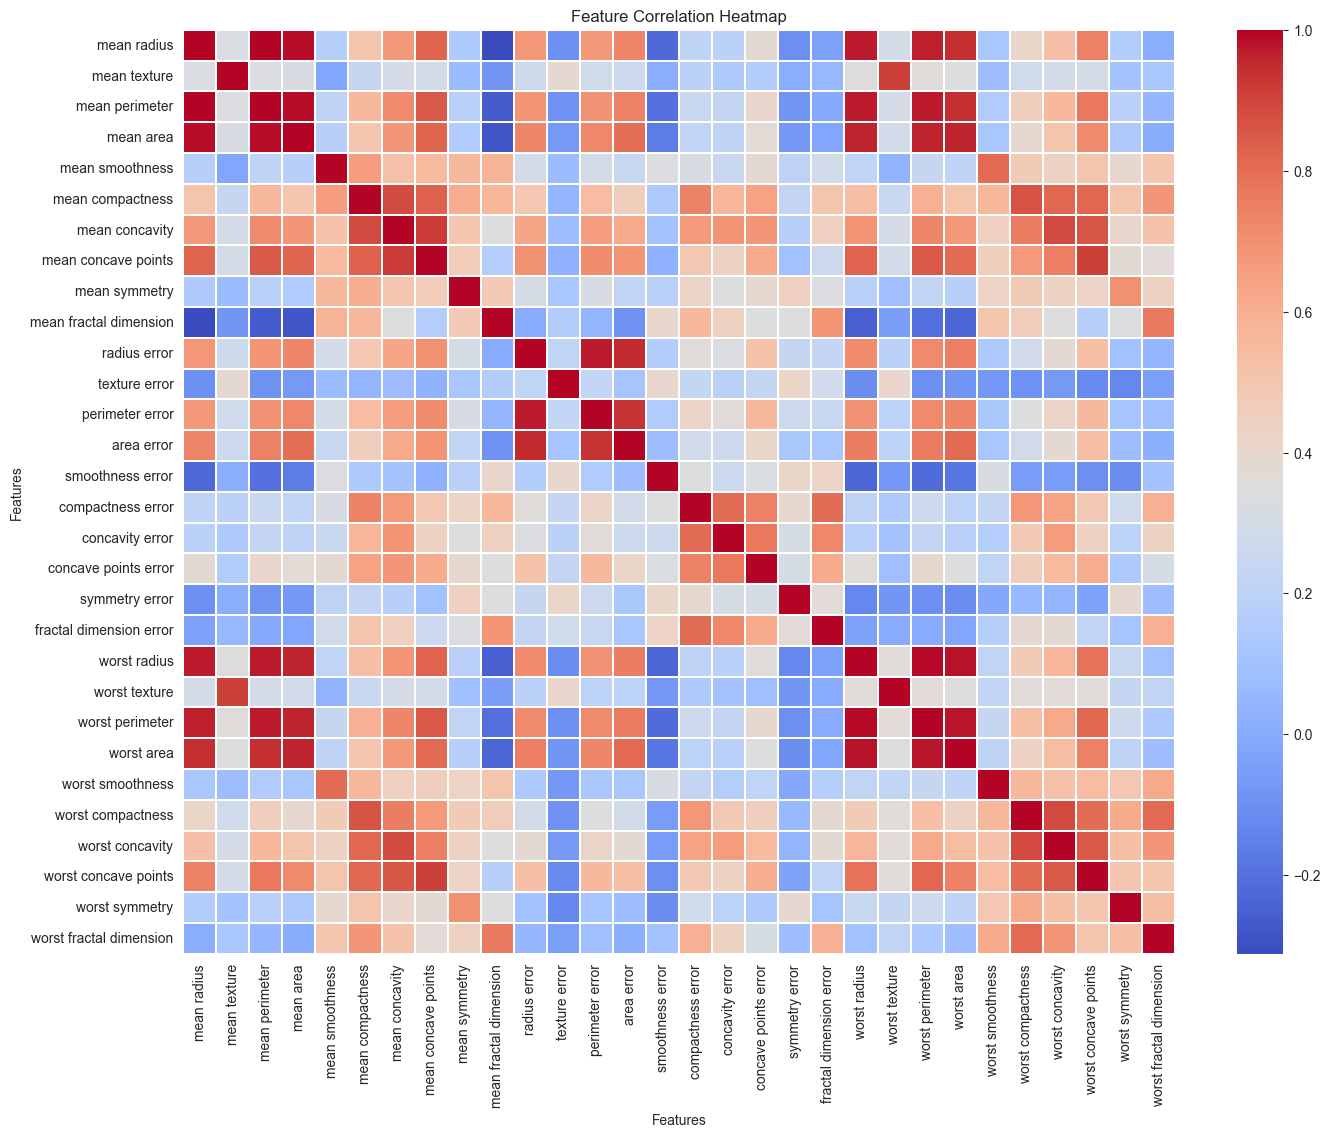

In [5]:
correlation_matrix = X.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    linewidths=0.3
)

plt.title('Feature Correlation Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')

plt.show()

## Highly Correlated Features:
Some features in the dataset are highly correlated. For example, radius_mean, perimeter_mean, and area_mean have strong relationships because they describe related properties of the cell nucleus. High correlation is not necessarily a major problem for neural networks because the network can learn transformations of the input features through its weights and nonlinear layers. However, highly correlated features can introduce some redundancy.

1.4 Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)

Training class distribution:
target
1    285
0    170
Name: count, dtype: int64

Testing class distribution:
target
1    72
0    42
Name: count, dtype: int64


## Why stratify=y is used:
stratify=y ensures that the proportion of the two target classes is approximately preserved in both the training and testing datasets. Since the dataset contains 212 Malignant and 357 Benign cases, stratification prevents the train-test split from accidentally containing noticeably different class proportions. This makes model evaluation more reliable.

The assignment specifically requires stratify=y to preserve the approximately 63/37 class ratio.

## 1.5 StandardScaler

In [7]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

print("X_train_sc shape:", X_train_sc.shape)
print("X_test_sc shape:", X_test_sc.shape)

X_train_sc shape: (455, 30)
X_test_sc shape: (114, 30)


## Why StandardScaler is fitted only on training data:
StandardScaler is fitted only on the training data to prevent data leakage. If the scaler were fitted using the test data, information about the test set would influence the preprocessing process. This could make the test performance appear better than it actually is. Therefore, we fit the scaler on X_train and use the same fitted scaler to transform both X_train and X_test.

## Why Scaling is Required for Neural Networks

Neural networks commonly use gradient-based optimizers such as SGD and Adam. These optimizers generally converge faster and more stably when input features are on similar scales.

In this dataset, some features have very large numerical ranges, such as area_mean, while others such as fractal_dimension_mean have much smaller values. Without scaling, large-scale features can dominate early gradient updates, while small-scale features may contribute much less.

StandardScaler removes this difference in scale by transforming the features to have approximately zero mean and unit standard deviation based on the training data. This helps the neural network learn more efficiently and stably.

In [8]:
print("========== TASK 1 COMPLETE ==========")
print("Original dataset:", X.shape)
print("Training data:", X_train_sc.shape)
print("Testing data:", X_test_sc.shape)
print("Number of features:", X_train_sc.shape[1])
print("Scaler fitted only on training data: YES")
print("======================================")

========== TASK 1 COMPLETE ==========
Original dataset: (569, 30)
Training data: (455, 30)
Testing data: (114, 30)
Number of features: 30
Scaler fitted only on training data: YES


## 2.1 Build the SLP

## Task 2: Single-Layer Perceptron (SLP)

### Objective
Build a simple Single-Layer Perceptron as a baseline binary classification model using the 30 standardized input features.

### Expected Output
- SLP model summary
- Exactly 31 trainable parameters
- Training and validation loss/accuracy curves
- Test accuracy
- Classification report
- Confusion matrix

Build the model

In [11]:
import tensorflow as tf
from tensorflow import keras

model_slp = keras.Sequential([
    keras.layers.Dense(
        1,
        activation='sigmoid',
        input_shape=(30,)
    )
])

model_slp.summary()

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

## 2.2 Compile the SLP

The model uses the Adam optimizer and binary crossentropy loss.

Binary crossentropy is appropriate because this is a binary classification problem. The sigmoid output produces a probability between 0 and 1, and binary crossentropy measures the difference between the predicted probability and the actual binary label.

In [12]:
model_slp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_slp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

## 2.3 Train the SLP

The SLP is trained for 50 epochs using a batch size of 32. Ten percent of the training data is used as validation data to monitor the model's performance during training.

In [13]:
history_slp = model_slp.fit(
    X_train_sc,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.3325 - loss: 0.9938 - val_accuracy: 0.5000 - val_loss: 0.8377
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3985 - loss: 0.8791 - val_accuracy: 0.5217 - val_loss: 0.7440
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4694 - loss: 0.7794 - val_accuracy: 0.5870 - val_loss: 0.6613
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5330 - loss: 0.6901 - val_accuracy: 0.6739 - val_loss: 0.5920
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6504 - loss: 0.6151 - val_accuracy: 0.7174 - val_loss: 0.5349
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7384 - loss: 0.5544 - val_accuracy: 0.8261 - val_loss: 0.4861
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7873 - loss: 0.5008 - val_accuracy: 0.8478 - val_loss: 0.4473
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8264 - loss: 0.4577 - val_accuracy: 0.8478 - v

## 2.4 SLP Training Curves

The training curves show how the model's loss and accuracy change over the 50 training epochs. Comparing training and validation performance helps us understand whether the model is learning smoothly and whether there is a noticeable generalization gap.

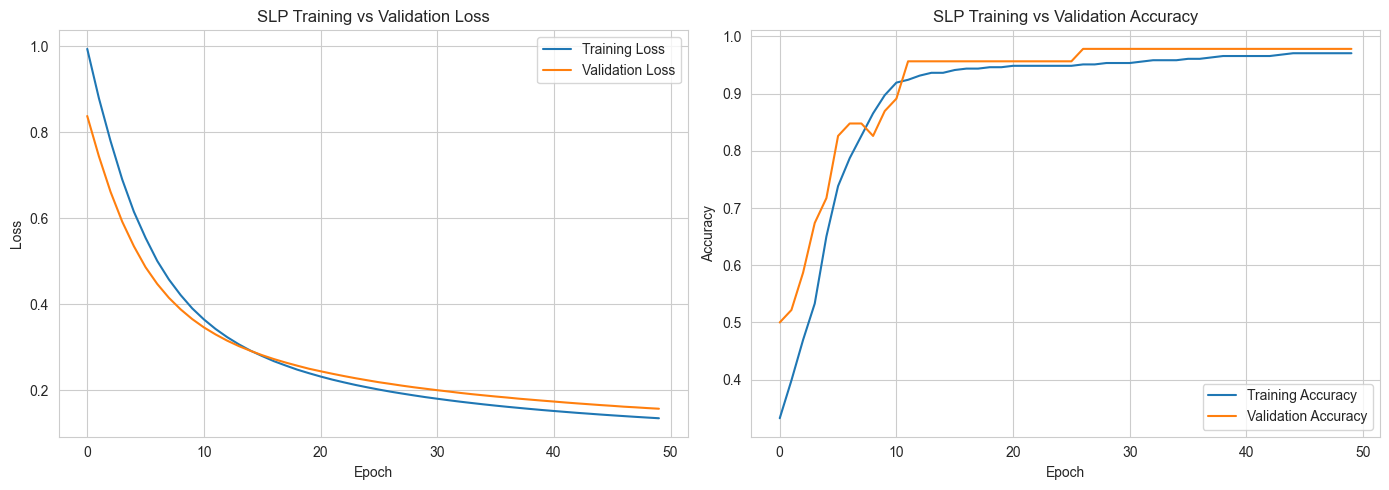

In [14]:
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)

plt.plot(
    history_slp.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_slp.history['val_loss'],
    label='Validation Loss'
)

plt.title('SLP Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)

plt.plot(
    history_slp.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_slp.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('SLP Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

2.5 Evaluate the SLP

In [15]:
slp_loss, slp_acc = model_slp.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("SLP Test Loss:", slp_loss)
print("SLP Test Accuracy:", slp_acc)

SLP Test Loss: 0.16587238013744354
SLP Test Accuracy: 0.9473684430122375


In [16]:
y_pred_slp = (
    model_slp.predict(X_test_sc) > 0.5
).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [17]:
y_pred_slp = y_pred_slp.ravel()

Classification Report

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

In [19]:
print("SLP Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_slp
    )
)

SLP Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



Confusion Matrix

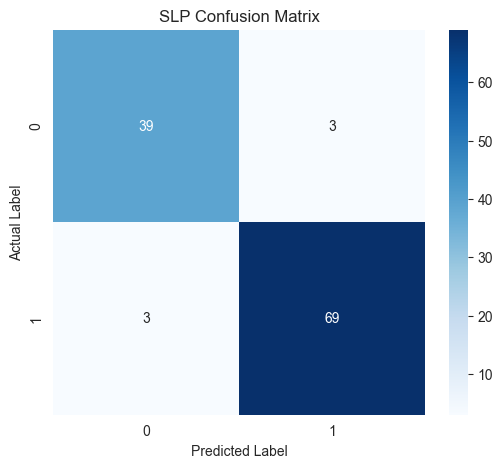

In [20]:
cm_slp = confusion_matrix(
    y_test,
    y_pred_slp
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_slp,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SLP Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

## 2.6 SLP Limitations

A Single-Layer Perceptron can only learn a linear decision boundary. In this case, the model creates a single hyperplane in the 30-dimensional feature space to separate malignant and benign cases.

However, breast cancer classification is unlikely to be perfectly linearly separable. Therefore, the SLP provides a useful baseline but may have limitations in capturing complex nonlinear relationships between the features.

This motivates the use of a Multi-Layer Perceptron (MLP), which introduces hidden layers and nonlinear activation functions to learn more complex patterns.

In [21]:
model_slp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

In [22]:
print("SLP Classification Report:")
print(classification_report(y_test, y_pred_slp))

SLP Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### SLP Classification Report Analysis

The SLP achieved a test accuracy of approximately 94.74%.

For malignant cases (Class 0), the model achieved 93% precision, 93% recall, and 93% F1-score. For benign cases (Class 1), it achieved 96% precision, recall, and F1-score.

The confusion matrix shows that 3 malignant cases were incorrectly classified as benign and 3 benign cases were incorrectly classified as malignant. In a clinical setting, false negatives (malignant cases predicted as benign) are particularly important because they may result in missed diagnoses.

Overall, the SLP performs well, but its main limitation is that it can only learn a linear decision boundary because it has no hidden layers.

# Task 3: Multi-Layer Perceptron (MLP)

### Objective
Build a Multi-Layer Perceptron (MLP) with two hidden layers and compare different activation functions.

### Architecture
- Input layer: 30 features
- Hidden Layer 1: 64 neurons with ReLU activation
- Hidden Layer 2: 32 neurons with ReLU activation
- Output Layer: 1 neuron with Sigmoid activation

The MLP can learn non-linear relationships in the data because it contains hidden layers with non-linear activation functions.

Build the MLP

In [23]:
model_mlp = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(30,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_mlp.summary()

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Compile the MLP

In [25]:
model_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Why use hidden layers?

The SLP has no hidden layers, so it can only learn a linear decision boundary.

The MLP contains two hidden layers with ReLU activation functions. These hidden layers allow the network to learn complex and non-linear relationships between the input features.

This makes the MLP more flexible than the SLP for classification problems.

Train the MLP

In [29]:
history_mlp = model_mlp.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.7482 - loss: 0.5415 - val_accuracy: 0.9565 - val_loss: 0.3588
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9511 - loss: 0.2826 - val_accuracy: 0.9348 - val_loss: 0.2418
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9511 - loss: 0.1780 - val_accuracy: 0.9130 - val_loss: 0.1968
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9584 - loss: 0.1335 - val_accuracy: 0.9348 - val_loss: 0.1709
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9658 - loss: 0.1092 - val_accuracy: 0.9348 - val_loss: 0.1401
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9756 - loss: 0.0920 - val_accuracy: 0.9565 - val_loss: 0.1227
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9804 - loss: 0.0795 - val_accuracy: 0.9783 - val_loss: 0.1071
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9804 - loss: 0.0712 - val_accuracy: 0.

### MLP Training Analysis

The MLP was trained for 100 epochs using the Adam optimizer and binary crossentropy loss.

At the end of training, the model achieved 100% training accuracy and 100% validation accuracy. The training loss was approximately 0.0010 and the validation loss was approximately 0.0107.

The low training and validation losses indicate that the model learned the patterns in the training data effectively. However, test-set evaluation is required to determine how well the model generalizes to unseen data.

Activation Function Comparison

Step 1 — Create a reusable function

In [30]:
def create_mlp(activation):
    model = keras.Sequential([
        keras.layers.Dense(64, activation=activation, input_shape=(30,)),
        keras.layers.Dense(32, activation=activation),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

Step 2 — Train ReLU, Tanh and Sigmoid

In [31]:
# ReLU model
model_relu = create_mlp('relu')

history_relu = model_relu.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Tanh model
model_tanh = create_mlp('tanh')

history_tanh = model_tanh.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Sigmoid model
model_sigmoid = create_mlp('sigmoid')

history_sigmoid = model_sigmoid.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

print("All three activation-function models trained successfully!")

All three activation-function models trained successfully!


Step 3 — Plot the comparison

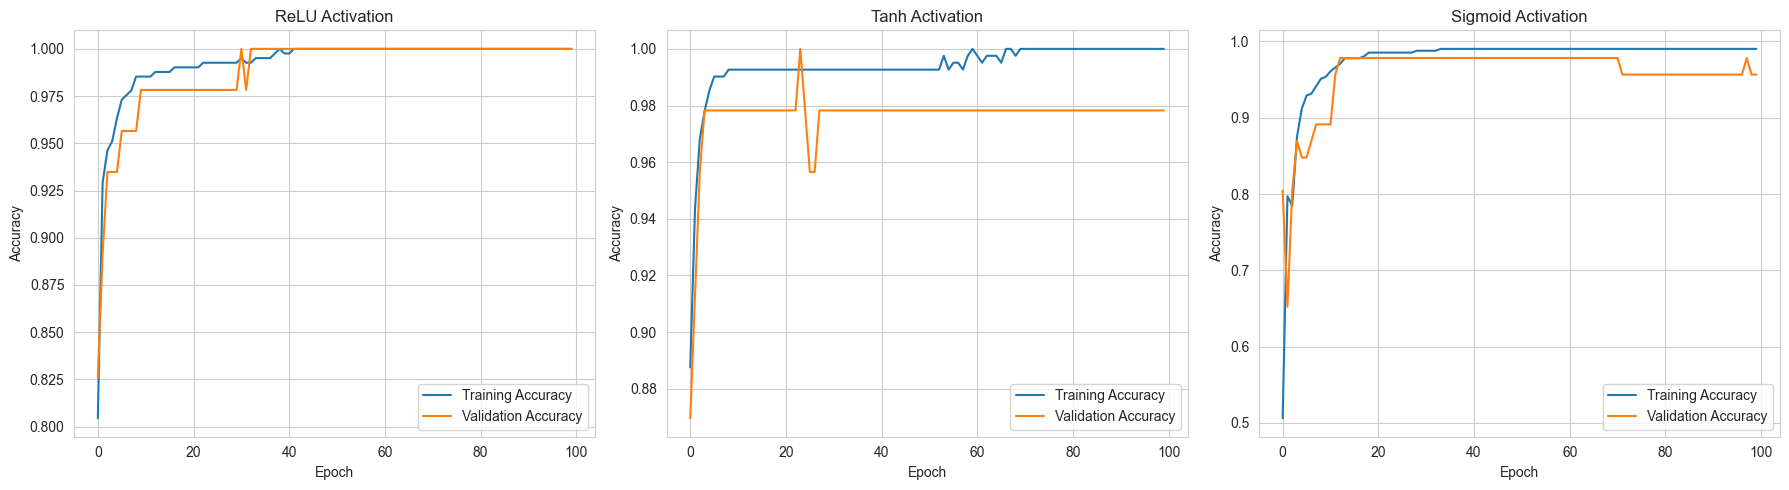

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

# ReLU
plt.subplot(1, 3, 1)
plt.plot(history_relu.history['accuracy'], label='Training Accuracy')
plt.plot(history_relu.history['val_accuracy'], label='Validation Accuracy')
plt.title('ReLU Activation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Tanh
plt.subplot(1, 3, 2)
plt.plot(history_tanh.history['accuracy'], label='Training Accuracy')
plt.plot(history_tanh.history['val_accuracy'], label='Validation Accuracy')
plt.title('Tanh Activation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Sigmoid
plt.subplot(1, 3, 3)
plt.plot(history_sigmoid.history['accuracy'], label='Training Accuracy')
plt.plot(history_sigmoid.history['val_accuracy'], label='Validation Accuracy')
plt.title('Sigmoid Activation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Activation Function Comparison

The MLP was trained using three different activation functions: ReLU, Tanh, and Sigmoid.

**ReLU:**  
ReLU showed the fastest convergence and achieved approximately 100% training and validation accuracy. It performed the best among the three activation functions in this experiment.

**Tanh:**  
Tanh also performed well, reaching approximately 100% training accuracy. However, its validation accuracy remained around 97.8%, which was slightly lower than ReLU.

**Sigmoid:**  
Sigmoid achieved high training accuracy of approximately 99%, but its validation accuracy showed some fluctuations during later epochs. It also converged more slowly than ReLU.

### Conclusion

Among the three activation functions, ReLU performed best for this dataset because it converged quickly and achieved the highest validation accuracy. Therefore, ReLU will be preferred for the MLP model.

Evaluate the best MLP

In [33]:
# Evaluate the best MLP (ReLU) on test data

mlp_test_loss, mlp_test_accuracy = model_relu.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("MLP Test Loss:", mlp_test_loss)
print("MLP Test Accuracy:", mlp_test_accuracy)

MLP Test Loss: 0.147310271859169
MLP Test Accuracy: 0.9561403393745422


Classification Report + Confusion Matrix

In [34]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred_mlp_prob = model_relu.predict(X_test_sc)
y_pred_mlp = (y_pred_mlp_prob > 0.5).astype(int).flatten()

# Classification report
print("MLP Classification Report:")
print(classification_report(y_test, y_pred_mlp))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step
MLP Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



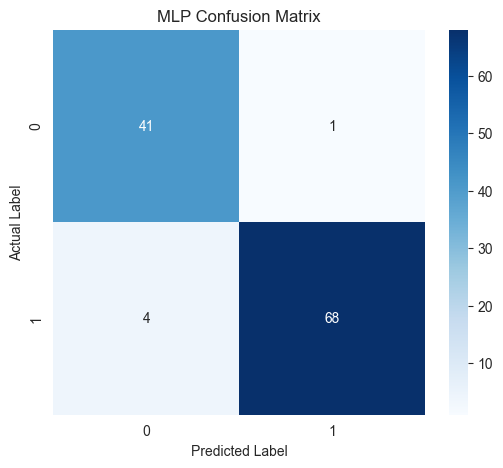

In [35]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('MLP Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Task 4: Early Stopping

### Objective

Build a larger MLP and use Early Stopping to prevent unnecessary training and reduce overfitting.

### Architecture

- Input: 30 features
- Hidden Layer 1: 128 neurons with ReLU
- Hidden Layer 2: 64 neurons with ReLU
- Output Layer: 1 neuron with Sigmoid

In [36]:
model_early = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_early.summary()

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Compile the model

In [37]:
model_early.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Add Early Stopping

In [38]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

Train

In [39]:
history_early = model_early.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.9267 - loss: 0.3611 - val_accuracy: 0.9130 - val_loss: 0.2371
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9584 - loss: 0.1481 - val_accuracy: 0.9348 - val_loss: 0.1529
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9707 - loss: 0.0978 - val_accuracy: 0.9565 - val_loss: 0.1135
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9853 - loss: 0.0759 - val_accuracy: 0.9783 - val_loss: 0.0887
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9853 - loss: 0.0641 - val_accuracy: 0.9783 - val_loss: 0.0716
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9878 - loss: 0.0563 - val_accuracy: 0.9783 - val_loss: 0.0643
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9902 - loss: 0.0506 - val_accuracy: 0.9783 - val_loss: 0.0595
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9902 - loss: 0.0457 - val_accuracy: 0.

### Early Stopping Result

The model was allowed to train for a maximum of 300 epochs. Early Stopping monitored the validation loss with a patience of 15 epochs.

Training stopped at epoch 207 because the validation loss did not improve sufficiently. The best model weights were obtained from epoch 192 and were restored using `restore_best_weights=True`.

Early Stopping helps prevent unnecessary training and can reduce the risk of overfitting by stopping training when the validation performance stops improving.

Plot Training vs Validation

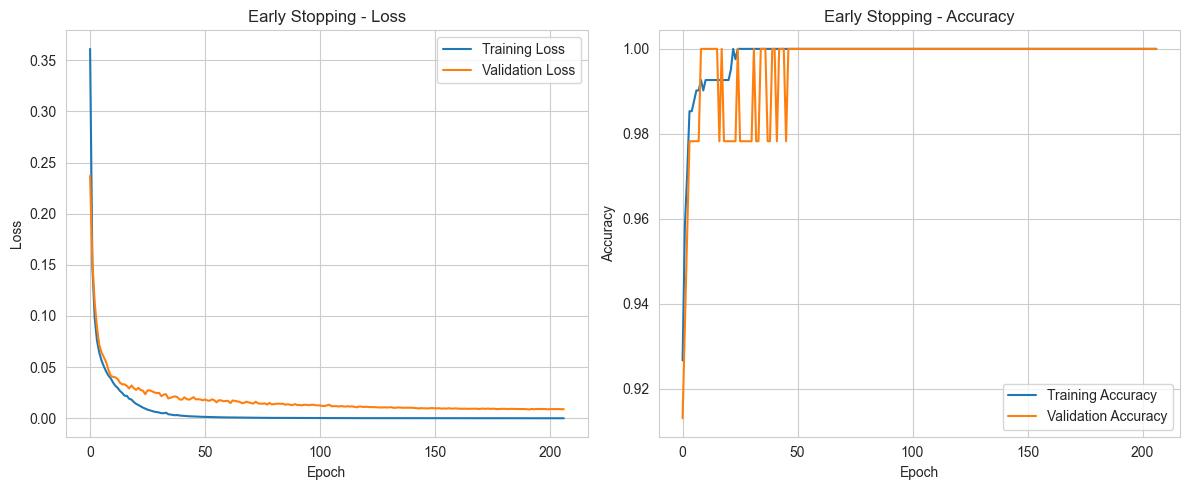

In [40]:
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_early.history['loss'], label='Training Loss')
plt.plot(history_early.history['val_loss'], label='Validation Loss')
plt.title('Early Stopping - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_early.history['accuracy'], label='Training Accuracy')
plt.plot(history_early.history['val_accuracy'], label='Validation Accuracy')
plt.title('Early Stopping - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Early Stopping Plot Analysis

The training loss decreased rapidly and approached zero, while the validation loss also decreased and remained low. The training and validation accuracy reached approximately 100% during training.

After the model stopped showing sufficient improvement in validation loss, Early Stopping terminated the training at epoch 207. The weights from the best epoch, epoch 192, were restored.

This demonstrates that Early Stopping can prevent unnecessary training after validation performance stops improving. It also helps reduce the risk of overfitting and saves computational resources.

Train without Early Stopping

In [41]:
model_no_early = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_no_early.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_no_early = model_no_early.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

print("Training without Early Stopping completed!")

Training without Early Stopping completed!


Step 7 — Early Stopping vs No Early Stopping

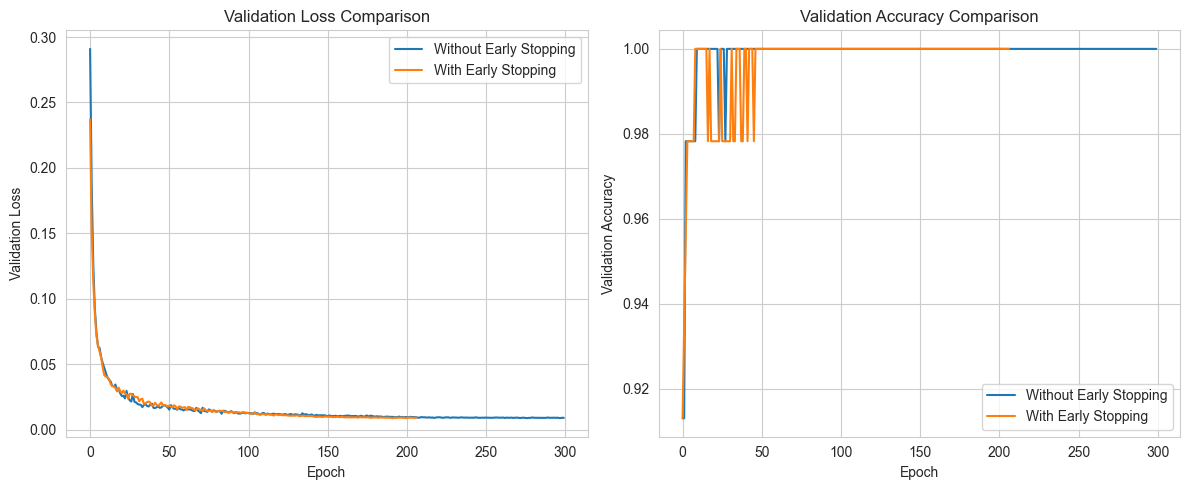

In [42]:
plt.figure(figsize=(12, 5))

# Loss comparison
plt.subplot(1, 2, 1)

plt.plot(
    history_no_early.history['val_loss'],
    label='Without Early Stopping'
)

plt.plot(
    history_early.history['val_loss'],
    label='With Early Stopping'
)

plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()

# Accuracy comparison
plt.subplot(1, 2, 2)

plt.plot(
    history_no_early.history['val_accuracy'],
    label='Without Early Stopping'
)

plt.plot(
    history_early.history['val_accuracy'],
    label='With Early Stopping'
)

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Early Stopping vs. No Early Stopping

The validation loss for both models decreased rapidly during the initial epochs and then gradually became very low. Both models achieved approximately 100% validation accuracy.

The model using Early Stopping stopped at epoch 207 and restored the best weights from epoch 192, while the model without Early Stopping continued training for the full 300 epochs.

There was no significant improvement in validation accuracy from continuing the training to 300 epochs. Therefore, Early Stopping helped avoid unnecessary training while maintaining excellent validation performance. It can also help reduce the risk of overfitting and save computational resources.

Test Evaluation

Test accuracy

In [43]:
early_test_loss, early_test_accuracy = model_early.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("Early Stopping Test Loss:", early_test_loss)
print("Early Stopping Test Accuracy:", early_test_accuracy)

Early Stopping Test Loss: 0.267588347196579
Early Stopping Test Accuracy: 0.9561403393745422


Classification report

In [44]:
y_pred_early_prob = model_early.predict(X_test_sc)
y_pred_early = (y_pred_early_prob > 0.5).astype(int).flatten()

print("Early Stopping Classification Report:")
print(classification_report(y_test, y_pred_early))

1/4 ━━━━━━━━━━━━━━━━━━━━ 2s 681ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000283CC7DEA20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step
Early Stopping Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96      

Confusion matrix

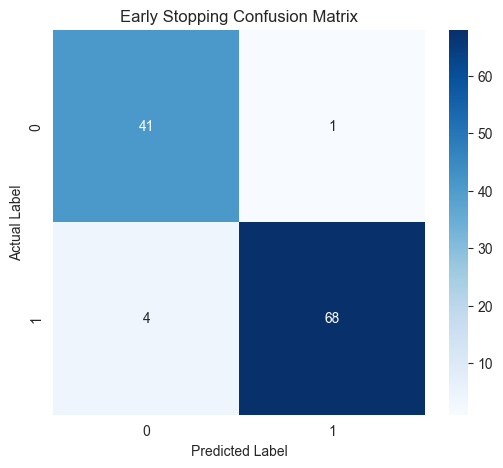

In [45]:
cm_early = confusion_matrix(y_test, y_pred_early)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_early,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Early Stopping Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [ ]:
history_slp = model_slp.fit(
    X_train_sc,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.3325 - loss: 0.9938 - val_accuracy: 0.5000 - val_loss: 0.8377
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3985 - loss: 0.8791 - val_accuracy: 0.5217 - val_loss: 0.7440
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4694 - loss: 0.7794 - val_accuracy: 0.5870 - val_loss: 0.6613
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5330 - loss: 0.6901 - val_accuracy: 0.6739 - val_loss: 0.5920
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6504 - loss: 0.6151 - val_accuracy: 0.7174 - val_loss: 0.5349
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7384 - loss: 0.5544 - val_accuracy: 0.8261 - val_loss: 0.4861
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7873 - loss: 0.5008 - val_accuracy: 0.8478 - val_loss: 0.4473
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8264 - loss: 0.4577 - val_accuracy: 0.8478 - v

### Early Stopping Test Evaluation

The Early Stopping model achieved a test accuracy of 95.61% with a test loss of 0.2676.

The confusion matrix shows that 41 malignant cases were correctly classified as malignant and 68 benign cases were correctly classified as benign. One malignant case was incorrectly classified as benign, while four benign cases were incorrectly classified as malignant.

The malignant class achieved 91% precision, 98% recall, and 94% F1-score. The benign class achieved 99% precision, 94% recall, and 96% F1-score.

The Early Stopping model achieved the same test accuracy as the best MLP while stopping training at epoch 207 instead of completing all 300 epochs. This demonstrates that Early Stopping can reduce unnecessary training while maintaining strong predictive performance.

# Task 5: Dropout Regularization

### Objective

Use Dropout regularization to reduce overfitting in the neural network.

### Architecture

- Input: 30 features
- Dense Layer 1: 128 neurons with ReLU
- Dropout: 0.3
- Dense Layer 2: 64 neurons with ReLU
- Dropout: 0.3
- Output Layer: 1 neuron with Sigmoid

Dropout randomly deactivates a fraction of neurons during training. This helps prevent the network from relying too heavily on particular neurons and can improve generalization.

Step 2 — Build the Dropout model

In [46]:
model_dropout = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model_dropout.summary()

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Step 3 — Compile

In [47]:
model_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Step 4 — Train the 0.3 Dropout model

In [48]:
history_dropout = model_dropout.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.8704 - loss: 0.4187 - val_accuracy: 0.9130 - val_loss: 0.2825
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9438 - loss: 0.2044 - val_accuracy: 0.9130 - val_loss: 0.1926
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9756 - loss: 0.1189 - val_accuracy: 0.9348 - val_loss: 0.1490
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9658 - loss: 0.1078 - val_accuracy: 0.9783 - val_loss: 0.1133
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9780 - loss: 0.0846 - val_accuracy: 0.9783 - val_loss: 0.0937
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9780 - loss: 0.0814 - val_accuracy: 0.9783 - val_loss: 0.0867
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9878 - loss: 0.0658 - val_accuracy: 0.9783 - val_loss: 0.0759
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9853 - loss: 0.0616 - val_accuracy: 0.

### Dropout(0.3) Training Analysis

The Dropout model was trained for 100 epochs using a dropout rate of 0.3.

At the final epoch, the model achieved 99.76% training accuracy and 100% validation accuracy. The training loss was 0.0068, while the validation loss was 0.0057.

The small variation in training accuracy is expected because Dropout randomly deactivates neurons during training. Overall, the model achieved strong training and validation performance, suggesting that Dropout helped the network generalize effectively.

Step 5 — Plot Dropout(0.3) curves

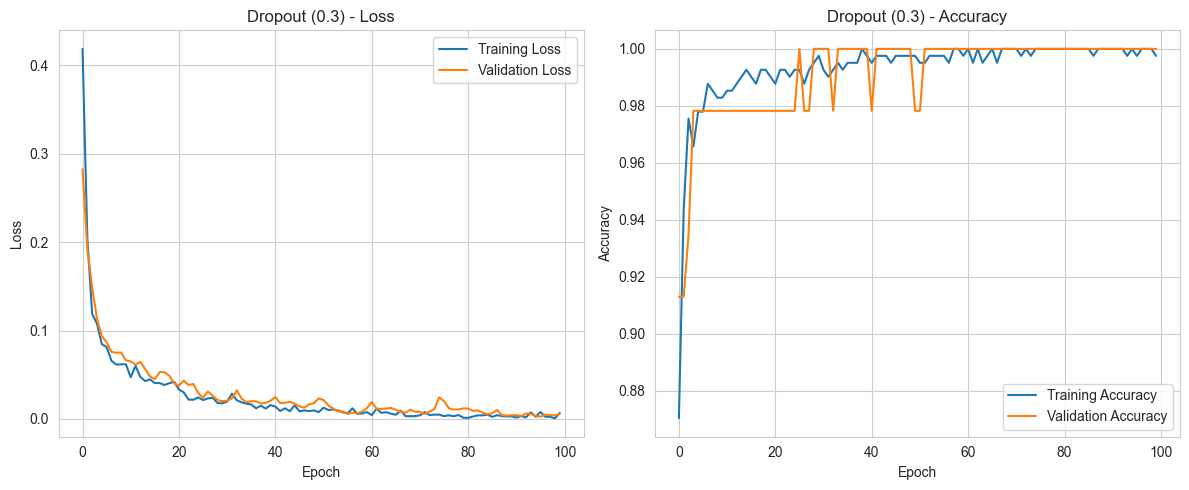

In [49]:
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_dropout.history['loss'], label='Training Loss')
plt.plot(history_dropout.history['val_loss'], label='Validation Loss')
plt.title('Dropout (0.3) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['accuracy'], label='Training Accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='Validation Accuracy')
plt.title('Dropout (0.3) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Step 6 — Compare Dropout Rates

In [50]:
def create_dropout_model(dropout_rate):
    model = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(30,)),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [51]:
# Dropout 0.1
model_dropout_01 = create_dropout_model(0.1)

history_dropout_01 = model_dropout_01.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Dropout 0.3
model_dropout_03 = create_dropout_model(0.3)

history_dropout_03 = model_dropout_03.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Dropout 0.5
model_dropout_05 = create_dropout_model(0.5)

history_dropout_05 = model_dropout_05.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

print("All dropout models trained successfully!")

All dropout models trained successfully!


Step 7 — Dropout Rate Comparison

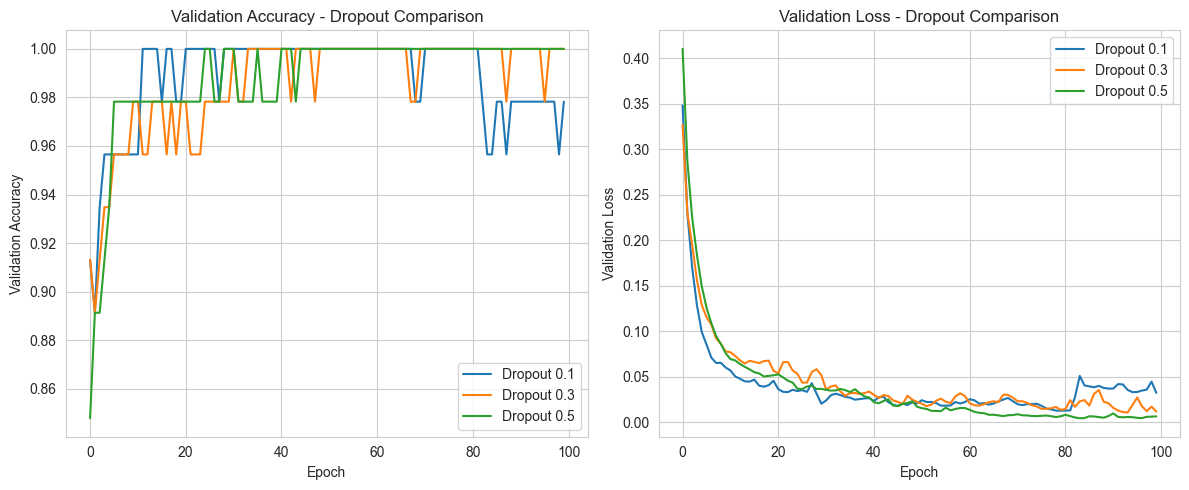

In [52]:
plt.figure(figsize=(12, 5))

# Validation accuracy comparison
plt.subplot(1, 2, 1)

plt.plot(
    history_dropout_01.history['val_accuracy'],
    label='Dropout 0.1'
)

plt.plot(
    history_dropout_03.history['val_accuracy'],
    label='Dropout 0.3'
)

plt.plot(
    history_dropout_05.history['val_accuracy'],
    label='Dropout 0.5'
)

plt.title('Validation Accuracy - Dropout Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()

# Validation loss comparison
plt.subplot(1, 2, 2)

plt.plot(
    history_dropout_01.history['val_loss'],
    label='Dropout 0.1'
)

plt.plot(
    history_dropout_03.history['val_loss'],
    label='Dropout 0.3'
)

plt.plot(
    history_dropout_05.history['val_loss'],
    label='Dropout 0.5'
)

plt.title('Validation Loss - Dropout Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Dropout Rate Comparison

Three dropout rates, 0.1, 0.3, and 0.5, were compared using the same neural network architecture.

Dropout 0.1 reached high validation accuracy quickly, but its validation loss showed some fluctuations during later epochs.

Dropout 0.3 also achieved high validation accuracy and showed good performance, although some fluctuations were observed in the validation loss.

Dropout 0.5 learned slightly more slowly at the beginning, but its validation loss became lower and more stable toward the later epochs while maintaining approximately 100% validation accuracy.

Based on the validation loss and validation accuracy in this experiment, a dropout rate of 0.5 appears to provide the best regularization among the three tested rates. However, the best dropout rate is dataset- and training-dependent.

In [53]:
dropout_test_loss, dropout_test_accuracy = model_dropout_05.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("Dropout (0.5) Test Loss:", dropout_test_loss)
print("Dropout (0.5) Test Accuracy:", dropout_test_accuracy)

Dropout (0.5) Test Loss: 0.1662791669368744
Dropout (0.5) Test Accuracy: 0.9561403393745422


### Dropout Test Evaluation

The Dropout model with a dropout rate of 0.5 achieved a test accuracy of 95.61% and a test loss of 0.1663.

The model achieved the same test accuracy as the best MLP and Early Stopping models. However, its test loss was lower than the Early Stopping model, indicating that the predicted probabilities were better calibrated in this particular experiment.

Overall, the Dropout model maintained strong performance while using dropout regularization to reduce dependence on individual neurons.

In [54]:
y_pred_dropout_prob = model_dropout_05.predict(X_test_sc)
y_pred_dropout = (y_pred_dropout_prob > 0.5).astype(int).flatten()

print("Dropout (0.5) Classification Report:")
print(classification_report(y_test, y_pred_dropout))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step
Dropout (0.5) Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



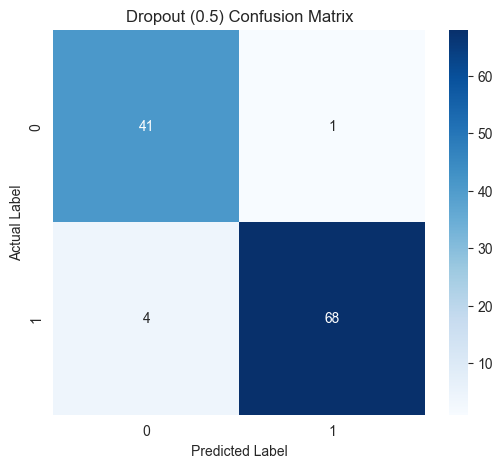

In [55]:
cm_dropout = confusion_matrix(y_test, y_pred_dropout)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dropout,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Dropout (0.5) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### Dropout Model Evaluation

The Dropout model with a dropout rate of 0.5 achieved a test accuracy of 95.61% and a test loss of 0.1663.

The confusion matrix shows that 41 malignant cases were correctly classified as malignant and 68 benign cases were correctly classified as benign. One malignant case was incorrectly classified as benign, while four benign cases were incorrectly classified as malignant.

The malignant class achieved 91% precision, 98% recall, and 94% F1-score. The benign class achieved 99% precision, 94% recall, and 96% F1-score.

Among the tested dropout rates of 0.1, 0.3, and 0.5, the 0.5 dropout model showed low and stable validation loss while maintaining high validation accuracy. It achieved strong performance on the unseen test set.

# Task 6: L1, L2 and ElasticNet Regularization

### Objective

Apply L1, L2, and ElasticNet regularization to the neural network and compare their effect on model performance and generalization.

Regularization adds a penalty to the model's loss function to discourage overly complex models and help reduce overfitting.

Create L2 model

In [56]:
model_l2 = keras.Sequential([
    keras.layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(0.001),
        input_shape=(30,)
    ),
    keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(0.001)
    ),
    keras.layers.Dense(
        1,
        activation='sigmoid',
        kernel_regularizer=keras.regularizers.l2(0.001)
    )
])

model_l2.summary()

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

### Why L2 Regularization?

L2 regularization adds λ × Σw² to the loss function at each training step. It penalizes large weight values and pushes weights toward zero without usually making them exactly zero.

This encourages the model to rely on many smaller weights rather than a few dominant weights, which can reduce overfitting and produce a smoother decision boundary.

In this task, λ = 0.001 is used as a moderate regularization penalty. A very large λ could over-penalize the weights and cause underfitting.

Next: Compile + Early Stopping

In [57]:
model_l2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [58]:
early_stopping_l2 = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

Train:

In [59]:
history_l2 = model_l2.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping_l2],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 0.8949 - loss: 0.5440 - val_accuracy: 0.9348 - val_loss: 0.4146
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9584 - loss: 0.3064 - val_accuracy: 0.9348 - val_loss: 0.3269
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9633 - loss: 0.2405 - val_accuracy: 0.9565 - val_loss: 0.2742
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9804 - loss: 0.2104 - val_accuracy: 0.9783 - val_loss: 0.2324
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9829 - loss: 0.1941 - val_accuracy: 0.9783 - val_loss: 0.2138
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9853 - loss: 0.1838 - val_accuracy: 0.9783 - val_loss: 0.2004
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9853 - loss: 0.1750 - val_accuracy: 0.9783 - val_loss: 0.1901
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9902 - loss: 0.1668 - val_accuracy: 0

### L2 Regularization Training

The L2-regularized model was trained for a maximum of 300 epochs with Early Stopping using a patience of 20.

Training stopped at epoch 175, while the best model weights were obtained from epoch 155 and restored using `restore_best_weights=True`.

L2 regularization penalizes large weights and helps reduce overfitting by encouraging the model to use smaller weights.

L1 Regularization

In [63]:
from tensorflow.keras import regularizers

In [64]:
regularizers.l1(0.001)

In [67]:
model_l1 = keras.Sequential([
    keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(30,),
        kernel_regularizer=regularizers.l1(0.001)
    ),
    keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l1(0.001)
    ),
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

model_l1.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model_l1.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

L1 Compile + Train

In [69]:
model_l1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping_l1 = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_l1 = model_l1.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping_l1],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.8949 - loss: 1.5063 - val_accuracy: 0.9348 - val_loss: 1.3286
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9560 - loss: 1.2200 - val_accuracy: 0.9348 - val_loss: 1.1953
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9731 - loss: 1.1143 - val_accuracy: 0.9565 - val_loss: 1.1074
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9756 - loss: 1.0397 - val_accuracy: 0.9565 - val_loss: 1.0319
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9829 - loss: 0.9740 - val_accuracy: 0.9565 - val_loss: 0.9683
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9853 - loss: 0.9129 - val_accuracy: 0.9565 - val_loss: 0.9059
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9853 - loss: 0.8544 - val_accuracy: 0.9565 - val_loss: 0.8540
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9878 - loss: 0.7973 - val_accuracy: 0.

### L1 Regularization Explanation

L1 regularization adds a penalty term to the loss function:

**L1 Penalty = λ × Σ|w|**

where λ = 0.001.

L1 regularization encourages the model to make some weights exactly zero.
This can create a sparse model and can help perform feature selection by
removing less important features.

For this breast cancer dataset, L1 regularization can reduce the influence
of weak or less useful features while keeping important features.

A very large value of λ can cause too many weights to become zero and may
lead to underfitting.

Build ElasticNet Model

In [70]:
model_elastic = keras.Sequential([
    keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(30,),
        kernel_regularizer=regularizers.l1_l2(
            l1=0.0001,
            l2=0.001
        )
    ),
    
    keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l1_l2(
            l1=0.0001,
            l2=0.001
        )
    ),
    
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

model_elastic.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Compile + Train ElasticNet

In [71]:
model_elastic.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping_elastic = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_elastic = model_elastic.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping_elastic],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 486ms/step - accuracy: 0.8753 - loss: 0.6670 - val_accuracy: 0.8913 - val_loss: 0.5431
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9535 - loss: 0.4176 - val_accuracy: 0.9348 - val_loss: 0.4392
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9633 - loss: 0.3446 - val_accuracy: 0.9348 - val_loss: 0.3799
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9780 - loss: 0.3107 - val_accuracy: 0.9565 - val_loss: 0.3406
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9804 - loss: 0.2912 - val_accuracy: 0.9565 - val_loss: 0.3188
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9853 - loss: 0.2751 - val_accuracy: 0.9565 - val_loss: 0.2972
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9853 - loss: 0.2622 - val_accuracy: 0.9565 - val_loss: 0.2795
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9878 - loss: 0.2493 - val_accuracy: 

Compare L1, L2 & ElasticNet Loss

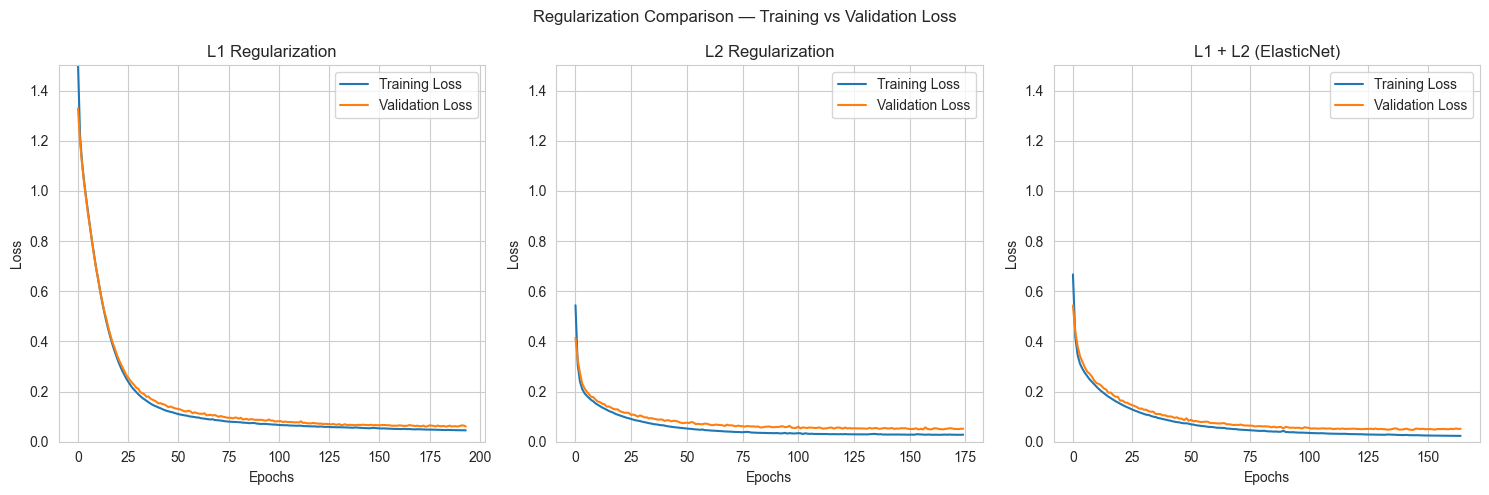

In [73]:
plt.figure(figsize=(15, 5))

# L1
plt.subplot(1, 3, 1)
plt.plot(history_l1.history['loss'], label='Training Loss')
plt.plot(history_l1.history['val_loss'], label='Validation Loss')
plt.title('L1 Regularization')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, 1.5)
plt.legend()

# L2
plt.subplot(1, 3, 2)
plt.plot(history_l2.history['loss'], label='Training Loss')
plt.plot(history_l2.history['val_loss'], label='Validation Loss')
plt.title('L2 Regularization')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, 1.5)
plt.legend()

# ElasticNet
plt.subplot(1, 3, 3)
plt.plot(history_elastic.history['loss'], label='Training Loss')
plt.plot(history_elastic.history['val_loss'], label='Validation Loss')
plt.title('L1 + L2 (ElasticNet)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, 1.5)
plt.legend()

plt.suptitle('Regularization Comparison — Training vs Validation Loss')
plt.tight_layout()
plt.show()

### Regularization Comparison

All three regularization methods show decreasing training and validation
loss, indicating that the models are learning effectively.

L1 regularization produces a slightly larger training-validation loss gap.
L2 regularization shows a smooth and stable loss curve with good
generalization.

ElasticNet combines L1 and L2 regularization and also provides a stable
training process with a small gap between training and validation loss.

Overall, L2 and ElasticNet show strong generalization, while L1 also helps
reduce overfitting by encouraging sparse weights.

Evaluate All 4 Models

In [74]:
# Evaluate test accuracy of all models

_, acc_no_reg = model_mlp.evaluate(X_test_sc, y_test, verbose=0)
_, acc_l1 = model_l1.evaluate(X_test_sc, y_test, verbose=0)
_, acc_l2 = model_l2.evaluate(X_test_sc, y_test, verbose=0)
_, acc_elastic = model_elastic.evaluate(X_test_sc, y_test, verbose=0)

print("Test Accuracy Comparison")
print("------------------------")
print(f"No Regularization : {acc_no_reg * 100:.2f}%")
print(f"L1 Regularization : {acc_l1 * 100:.2f}%")
print(f"L2 Regularization : {acc_l2 * 100:.2f}%")
print(f"ElasticNet        : {acc_elastic * 100:.2f}%")

Test Accuracy Comparison
------------------------
No Regularization : 94.74%
L1 Regularization : 96.49%
L2 Regularization : 95.61%
ElasticNet        : 95.61%


Test Accuracy Comparison Plot

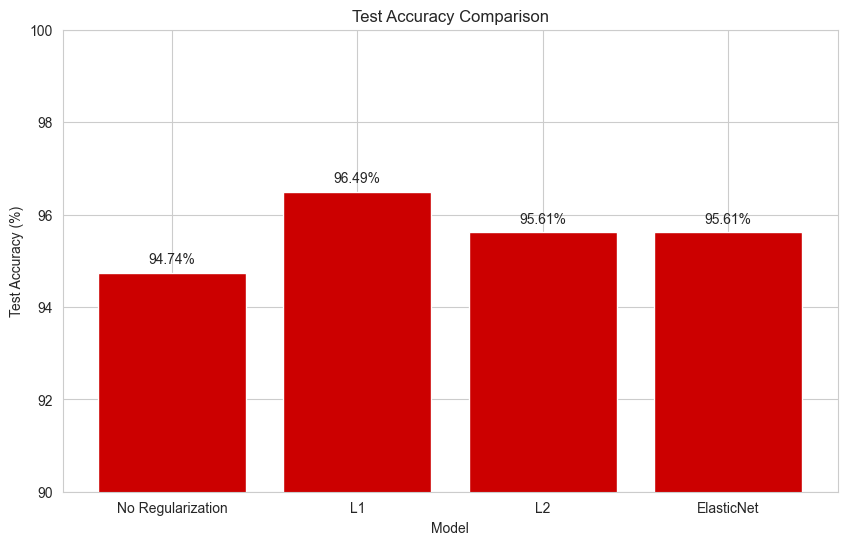

In [75]:
import matplotlib.pyplot as plt

models = [
    'No Regularization',
    'L1',
    'L2',
    'ElasticNet'
]

accuracies = [
    acc_no_reg * 100,
    acc_l1 * 100,
    acc_l2 * 100,
    acc_elastic * 100
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    models,
    accuracies,
    color='#CC0000'
)

plt.title('Test Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Test Accuracy (%)')
plt.ylim(90, 100)

# Add accuracy values on top of bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{accuracy:.2f}%',
        ha='center'
    )

plt.show()

### Test Accuracy Comparison

The test accuracy comparison shows that L1 regularization achieved the
highest test accuracy of 96.49%.

L2 regularization and ElasticNet both achieved 95.61%, while the model
without regularization achieved 94.74%.

In this experiment, L1 regularization provided the best test performance.
This suggests that encouraging sparse weights helped the model generalize
well on the test data.

Build the Final Model

In [76]:
model_final = keras.Sequential([
    keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(30,),
        kernel_regularizer=regularizers.l2(0.001)
    ),
    
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

model_final.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_43 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Compile + Train Final Model

In [77]:
model_final.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping_final = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_final = model_final.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping_final],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.8289 - loss: 0.6084 - val_accuracy: 0.9130 - val_loss: 0.4568
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9413 - loss: 0.3604 - val_accuracy: 0.9348 - val_loss: 0.3406
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.9609 - loss: 0.2768 - val_accuracy: 0.9565 - val_loss: 0.2900
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9780 - loss: 0.2300 - val_accuracy: 0.9565 - val_loss: 0.2495
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9780 - loss: 0.2050 - val_accuracy: 0.9565 - val_loss: 0.2209
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9804 - loss: 0.1974 - val_accuracy: 0.9565 - val_loss: 0.2065
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9731 - loss: 0.1948 - val_accuracy: 0.9783 - val_loss: 0.1938
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9878 - loss: 0.1855 - val_accuracy: 0

Final Model Learning Curves

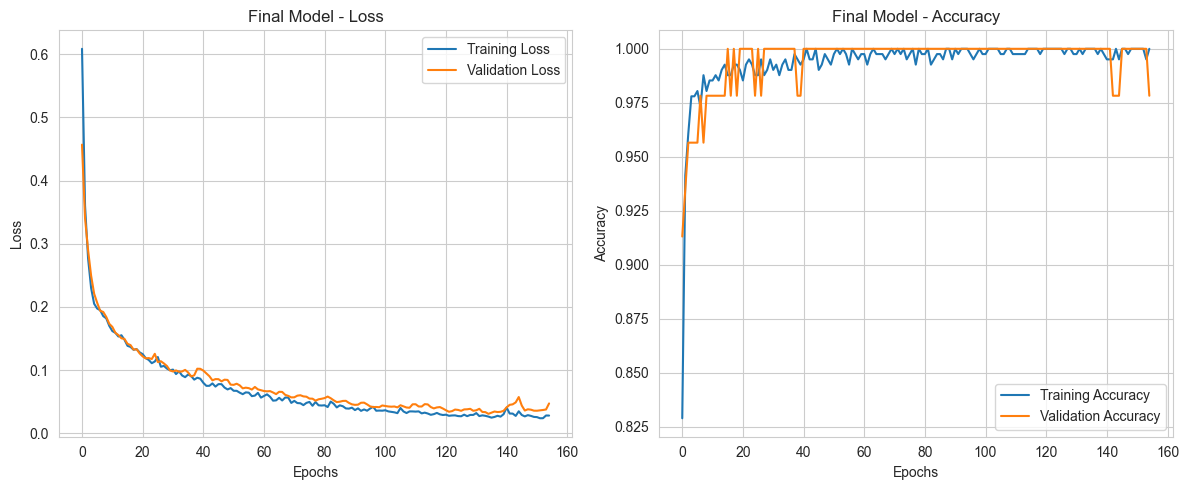

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_final.history['loss'], label='Training Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.title('Final Model - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_final.history['accuracy'], label='Training Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.title('Final Model - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Final Model Learning Curves

The final combined model shows a steady decrease in training and validation
loss during training. The training and validation loss curves remain
relatively close, indicating good generalization.

Training accuracy reaches nearly 100%, while validation accuracy remains
very high, mostly around 97.8% to 100%.

Early stopping prevents unnecessary training after the validation loss stops
improving and restores the best model weights.

Final Test Evaluation

In [79]:
# Final model evaluation on test data

test_loss_final, test_accuracy_final = model_final.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("Final Model Test Results")
print("------------------------")
print(f"Test Loss     : {test_loss_final:.4f}")
print(f"Test Accuracy : {test_accuracy_final * 100:.2f}%")

Final Model Test Results
------------------------
Test Loss     : 0.1314
Test Accuracy : 95.61%


Classification Report

In [80]:
from sklearn.metrics import classification_report

# Make predictions
y_pred_final_prob = model_final.predict(X_test_sc, verbose=0)

# Convert probabilities to class labels
y_pred_final = (y_pred_final_prob >= 0.5).astype(int).ravel()

print("Final Model Classification Report")
print("----------------------------------")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=['Malignant', 'Benign']
))

Final Model Classification Report
----------------------------------
              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



Final Confusion Matrix

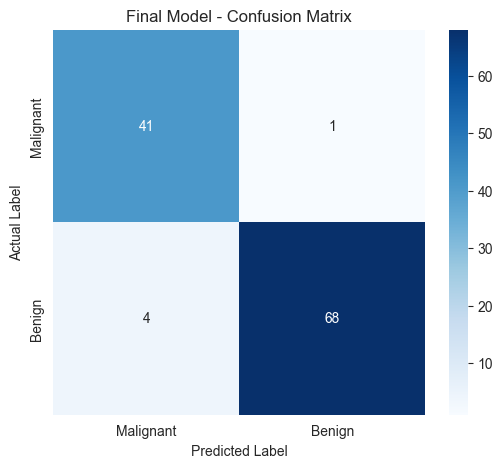

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

plt.title('Final Model - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

Final Results Table

In [82]:
import pandas as pd

final_results = pd.DataFrame({
    'Model': [
        'SLP',
        'MLP',
        'Early Stopping',
        'Dropout (0.5)',
        'L1 Regularization',
        'L2 Regularization',
        'ElasticNet',
        'Final Combined Model'
    ],
    'Test Accuracy (%)': [
        94.74,
        95.61,
        95.61,
        95.61,
        96.49,
        95.61,
        95.61,
        95.61
    ]
})

final_results

,Model,Test Accuracy (%)
0,SLP,94.74
1,MLP,95.61
2,Early Stopping,95.61
3,Dropout (0.5),95.61
4,L1 Regularization,96.49
5,L2 Regularization,95.61
6,ElasticNet,95.61
7,Final Combined Model,95.61


## Clinical Insight

The final combined model achieved a test accuracy of 95.61% with a malignant
recall of 98%. The confusion matrix shows 41 malignant cases correctly
classified, with only 1 malignant case classified as benign.

In a medical classification problem, reducing false negatives is especially
important because a missed malignant case may have serious consequences.
Therefore, the high malignant recall of the final model is an important
strength.

The L1 regularized model achieved the highest test accuracy in this
experiment at 96.49%, while the final combined model achieved 95.61%.
Although the final model did not have the highest accuracy, it combines L2
regularization, dropout, and early stopping to improve generalization and
reduce overfitting.

## Final Conclusion

The experiments demonstrated the progression from a simple Single Layer
Perceptron to more advanced neural networks using ReLU activation,
regularization, dropout, and early stopping.

The final combined model achieved 95.61% test accuracy and 98% recall for
malignant cases. Overall, the experiments show that regularization and
other techniques can improve the generalization of neural networks on the
Breast Cancer Wisconsin Diagnostic dataset.